# Projet — Classification des journaux pare-feu (SVM multiclasse)

Reprise de la méthodologie de **Ertam & Kaya (2018)** : quatre noyaux SVM (linéaire, polynomial, RBF, sigmoïde), métriques **précision / rappel / F1** (moyenne **macro**, en %), courbes **ROC par classe**.

Utilitaires : `firewall_svm.py`, `code/firewall_visualization.py`, `code/metric_interpretations.py`, `code/hyperparam_advisor.py`. Cwd dans Docker : `/workspace`.


In [1]:
# --- Configuration chemins (Docker : cwd = /workspace) ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
CODE = ROOT / "code"
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

import numpy as np
import pandas as pd

from firewall_svm import (
    ARTICLE_TABLE_III,
    CLASS_NAMES,
    FEATURE_NAMES,
    KERNEL_DISPLAY_NAMES,
    KERNEL_KEYS,
    RANDOM_STATE,
    load_data,
    optimize_best_model,
    prepare_data,
    select_features,
    train_eval_kernel,
)
from firewall_visualization import (
    plot_comparison_bar,
    plot_confusion_kernel,
    plot_roc_multiclass_single_kernel,
)
from visualization import (
    plot_firewall_action_distribution,
    plot_firewall_correlation_heatmap,
    plot_firewall_feature_boxplots,
    plot_firewall_reset_both_focus,
)
from metric_interpretations import (
    build_results_dataframe,
    print_article_vs_experiment,
    print_kernel_interpretation,
    print_crossrun_class_imbalance_bilan,
    print_threshold_tuning_bilan,
)
from hyperparam_advisor import print_kernel_hyperparam_advice
from run_timestamps import (
    ensure_minimum_fresh_runs,
    latest_finished_manifest,
    print_latest_run_legend,
)

RESULTS_STORE = {}
PIPE_STORE = {}

print("Racine :", ROOT.resolve())
print("Référence article (Table III) :", ARTICLE_TABLE_III)


Racine : /workspace
Référence article (Table III) : {'SVM Linear': {'F1 Score': 75.4, 'Precision': 67.5, 'Recall': 85.3}, 'SVM Polynomial': {'F1 Score': 53.6, 'Precision': 61.8, 'Recall': 47.4}, 'SVM RBF': {'F1 Score': 76.4, 'Precision': 63.0, 'Recall': 97.1}, 'SVM Sigmoid': {'F1 Score': 74.8, 'Precision': 60.3, 'Recall': 98.5}}


***Chargement des données (11 features, cible `Action`)***


In [2]:
# Fichier local relatif à la racine du dépôt, ou None pour simulation (65532 instances)
DATA_SOURCE = "log2.csv"

_log = print
df = load_data(_log, source=DATA_SOURCE if DATA_SOURCE else None)

print("\nAperçu :")
print(df.head())
print("\nDimensions :", df.shape)
print("\nEffectifs par classe :")
print(df["Action"].value_counts())

x, y_enc = select_features(_log, df)
x_train, x_test, y_train, y_test = prepare_data(_log, x, y_enc)
print("\nDécoupage stratifié, random_state =", RANDOM_STATE)


ÉTAPE 1 : Chargement des données
Source : log2.csv
Instances : 65532
Features : 11

Distribution des classes :
Action
allow         37640
deny          14987
drop          12851
reset-both       54

Aperçu :
   Source Port  Destination Port  NAT Source Port  NAT Destination Port  \
0        57222                53            54587                    53   
1        56258              3389            56258                  3389   
2         6881             50321            43265                 50321   
3        50553              3389            50553                  3389   
4        50002               443            45848                   443   

   Elapsed Time (sec)  Bytes  Bytes Sent  Bytes Received  Packets  pkts_sent  \
0                  30    177          94              83        2          1   
1                  17   4768        1600            3168       19         10   
2                1199    238         118             120        2          1   
3                  17

***Exploration des données (EDA) — représentations graphiques***

Les graphiques suivants résument:
- le déséquilibre des classes,
- les distributions des features par classe,
- les corrélations entre variables,
- un focus spécifique sur la classe rare `reset-both`.

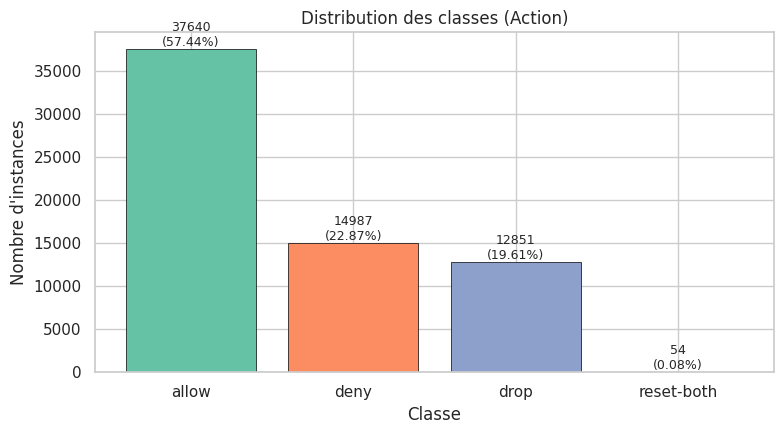

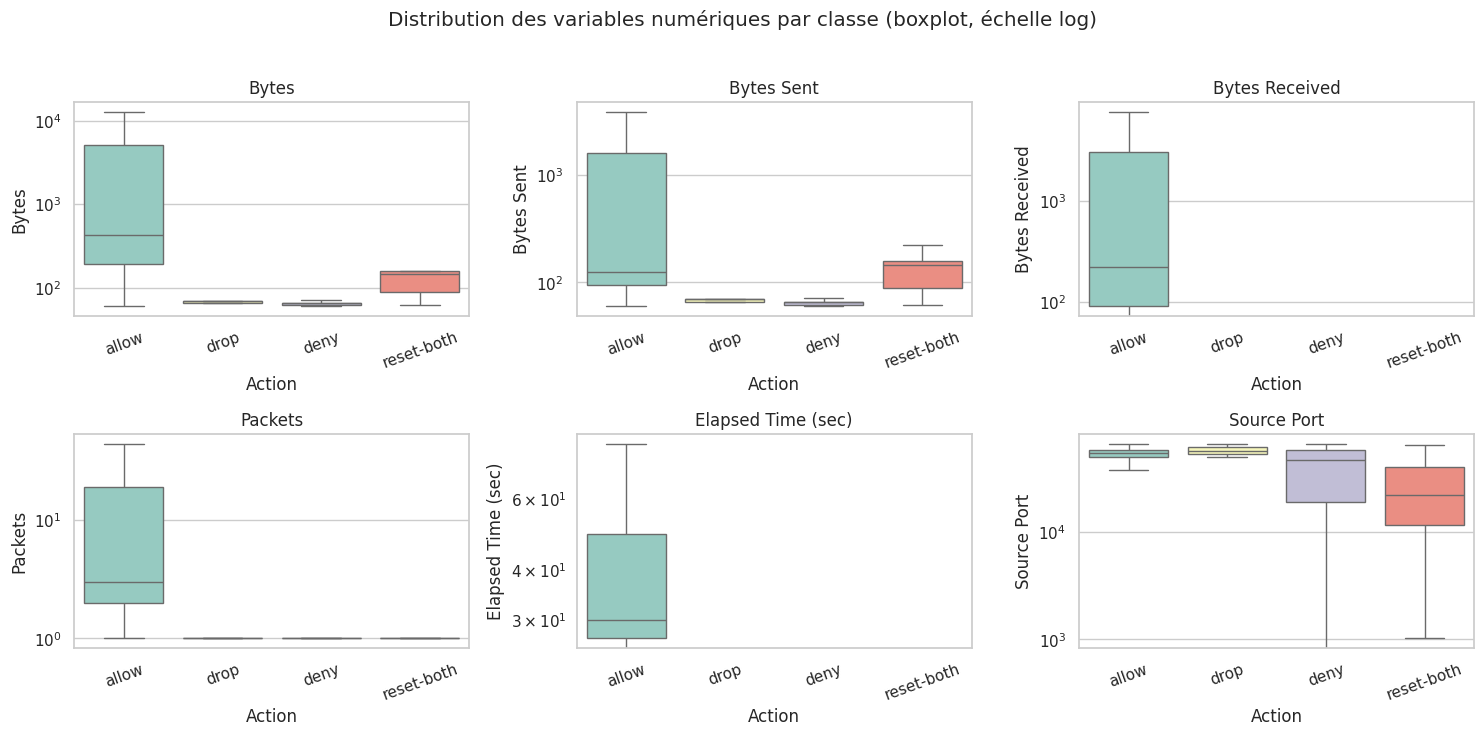

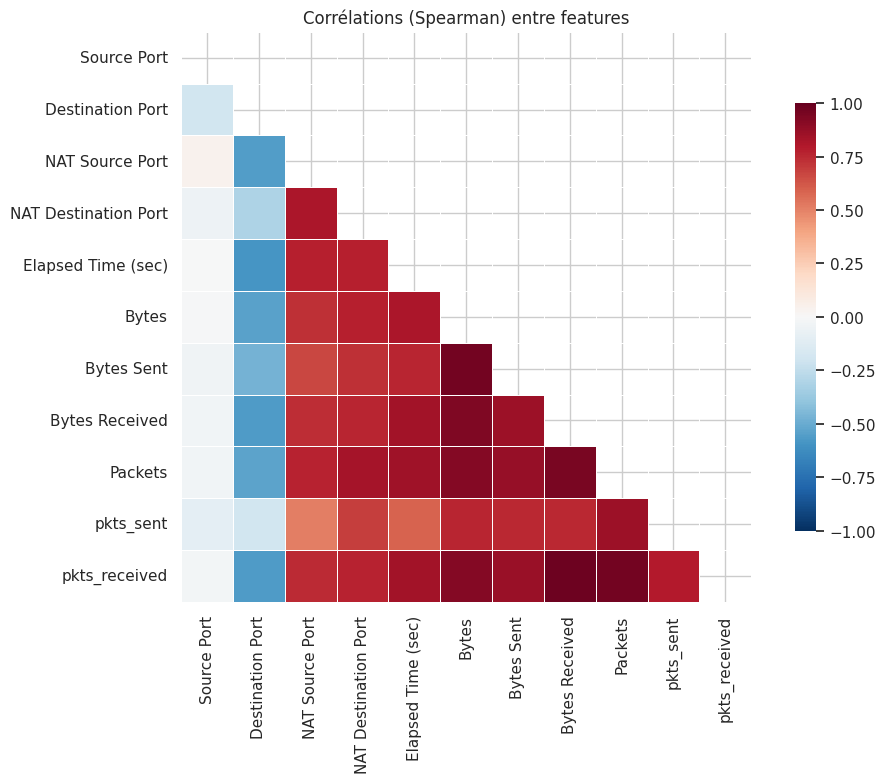

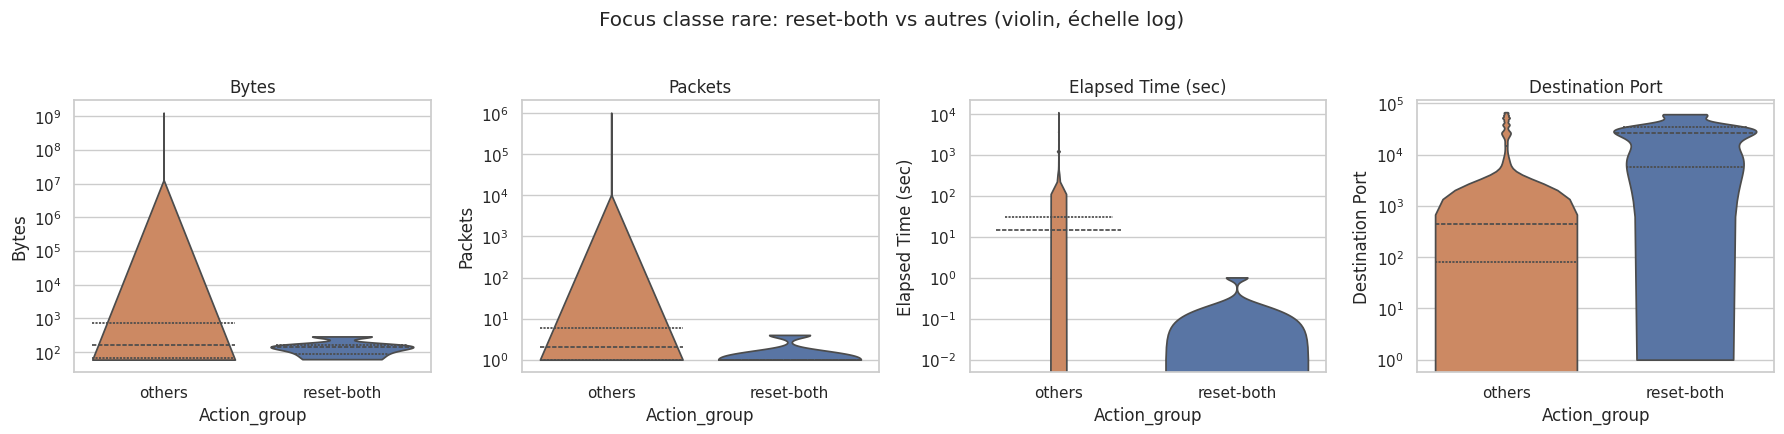

In [3]:
# EDA principal (visuels orientés rapport/soutenance)
plot_firewall_action_distribution(df)

plot_firewall_feature_boxplots(
    df,
    features=[
        "Bytes",
        "Bytes Sent",
        "Bytes Received",
        "Packets",
        "Elapsed Time (sec)",
        "Source Port",
    ],
    action_col="Action",
    ncols=3,
)

plot_firewall_correlation_heatmap(df, FEATURE_NAMES)

plot_firewall_reset_both_focus(
    df,
    features=["Bytes", "Packets", "Elapsed Time (sec)", "Destination Port"],
    action_col="Action",
    max_features=4,
)


***Synchronisation avec `firewall_svm.py` — horodatage et fraîcheur des runs***


In [4]:
# Vérifie qu'il existe au moins 2 runs terminés pour la source choisie.
# Si non, relance automatiquement la pipeline CLI le nombre de fois nécessaire.
MIN_RUNS_FOR_SOURCE = 2
MAX_RUN_AGE_SECONDS = 24 * 3600

from pathlib import Path

ROOT = Path.cwd()
_latest, _manifest, _count = ensure_minimum_fresh_runs(
    ROOT,
    min_runs=MIN_RUNS_FOR_SOURCE,
    max_age_seconds=MAX_RUN_AGE_SECONDS,
    data_source=DATA_SOURCE if DATA_SOURCE else None,
)
print(f"[notebook] runs disponibles pour la source active: {_count}")
print_latest_run_legend(ROOT, DATA_SOURCE if DATA_SOURCE else None)


[run_timestamps] Runs trouvés pour source='log2.csv': 0 (minimum requis=2)
[run_timestamps] Relance pipeline pour atteindre 2 runs (actuel=0)…
  Classification Firewall — SVM Multiclasse
  Dossier de run : run-20260413T033124Z/
  Horodatage début (UTC) : 2026-04-13T03:31:24.766768Z
ÉTAPE 1 : Chargement des données
Source : log2.csv
Instances : 65532
Features : 11

Distribution des classes :
Action
allow         37640
deny          14987
drop          12851
reset-both       54

ÉTAPE 2 : Sélection des features
11 features numériques sélectionnées
Variable cible : 'Action' (4 classes)
Données personnelles : exclues

ÉTAPE 3 : Préparation des données
Train : 52425 instances (80%)
Test : 13107 instances (20%)
Normalisation : StandardScaler appliquée

ÉTAPE 4 : Entraînement des 4 classifieurs SVM

 SVM Linear : 
F1=68.7%  Précision=74.3%  Rappel=83.1%

 SVM Polynomial : 
F1=65.8%  Précision=69.4%  Rappel=75.7%

 SVM RBF : 
F1=70.5%  Précision=73.2%  Rappel=81.6%

 SVM Sigmoid : 
F1=63.0%  P

***SVM linéaire***



  SVM Linear — scores globaux (moyenne « macro »)
  F1-score (harmonique P/R) : 68.7 %
  Précision                 : 74.3 %
  Rappel (sensibilité)      : 83.1 %
  (L'article Ertam & Kaya rapporte ces trois indicateurs par noyau ; F1 résume le compromis entre précision et rappel.)

--- Interprétation ---
• Le rappel macro domine la précision : le modèle retrouve davantage d'exemples réels par classe, au prix possible de plus de faux positifs.

• Classes peu représentées dans le jeu de test (exemples) : reset-both (n=11). Leur F1 par classe peut peser peu dans la moyenne macro mais être critique pour la sécurité (ex. reset-both).

--- Rapport par classe (support = effectifs test) ---
              precision    recall  f1-score   support

       allow       1.00      0.98      0.99      7528
        deny       1.00      0.62      0.76      2998
        drop       0.97      1.00      0.98      2570
  reset-both       0.01      0.73      0.01        11

    accuracy                        

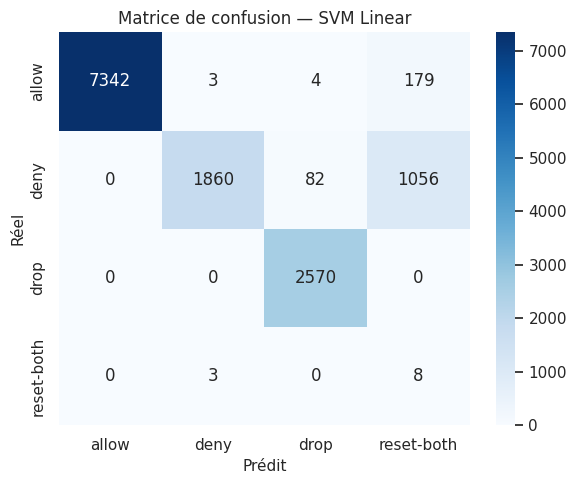

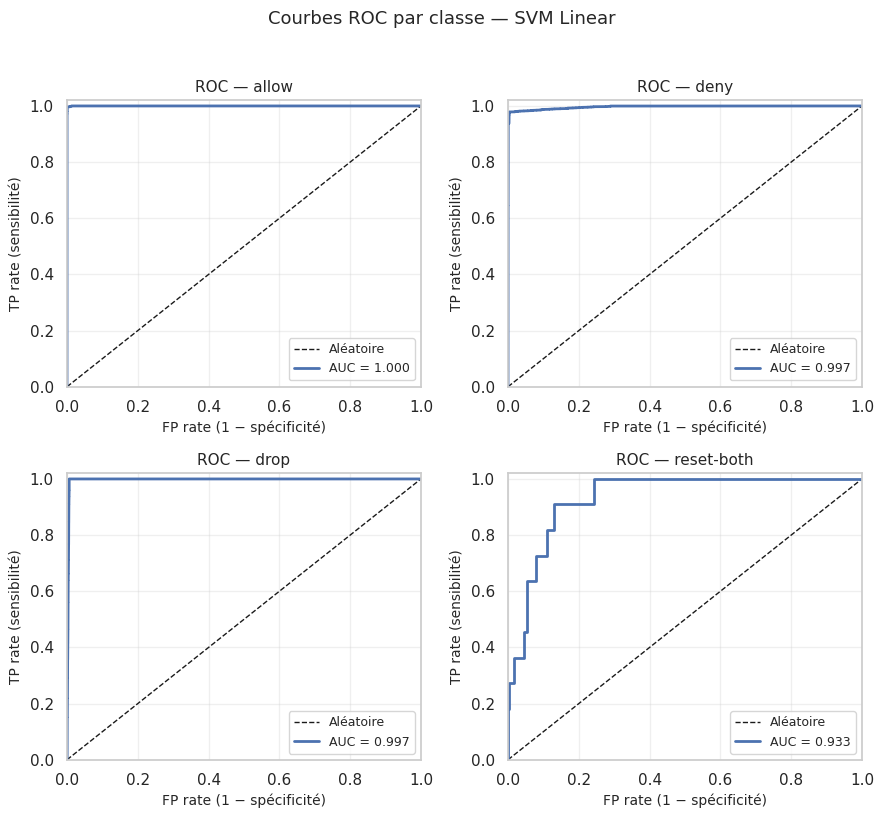


------------------------------------------------------------
  Conseils hyperparamètres — noyau « linear »
------------------------------------------------------------
Référence sklearn.svm.SVC (extraits) :
  C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0,
  class_weight=None, probability=False (nous utilisons probability=True pour les ROC).

Paramètres effectifs du modèle dans cette cellule :
  • C = 1.0
  • kernel = 'linear'
  • degree = 3
  • gamma = 'scale'
  • coef0 = 0.0
  • class_weight = 'balanced'
  • random_state = 69

--- Conseils par noyau ---
• Linear : seul C et class_weight influencent fortement. C plus grand → marge plus étroite, risque de sur-apprentissage ; C plus petit → marge large, peut sous-ajuster. Avec classes déséquilibrées, class_weight='balanced' aide le rappel des classes rares.

Pour une recherche systématique : utiliser GridSearchCV (fonction `optimize_best_model` dans `firewall_svm.py`) sur le jeu d'entraînement, métrique f1_macro, sans toucher 

In [5]:
KERNEL = "linear"
pipe, y_pred, metrics = train_eval_kernel(KERNEL, x_train, y_train, x_test, y_test)
RESULTS_STORE[KERNEL] = metrics
PIPE_STORE[KERNEL] = pipe

print_kernel_interpretation(
    KERNEL_DISPLAY_NAMES[KERNEL], y_test, y_pred, CLASS_NAMES, metrics
)
plot_confusion_kernel(
    y_test,
    y_pred,
    CLASS_NAMES,
    "Matrice de confusion — " + KERNEL_DISPLAY_NAMES[KERNEL],
)
y_score = pipe.predict_proba(x_test)
plot_roc_multiclass_single_kernel(
    y_test, y_score, CLASS_NAMES, KERNEL_DISPLAY_NAMES[KERNEL]
)
print_kernel_hyperparam_advice(KERNEL, pipe)


***SVM polynomial***



  SVM Polynomial — scores globaux (moyenne « macro »)
  F1-score (harmonique P/R) : 65.8 %
  Précision                 : 69.4 %
  Rappel (sensibilité)      : 75.7 %
  (L'article Ertam & Kaya rapporte ces trois indicateurs par noyau ; F1 résume le compromis entre précision et rappel.)

--- Interprétation ---
• Le rappel macro domine la précision : le modèle retrouve davantage d'exemples réels par classe, au prix possible de plus de faux positifs.

• Classes peu représentées dans le jeu de test (exemples) : reset-both (n=11). Leur F1 par classe peut peser peu dans la moyenne macro mais être critique pour la sécurité (ex. reset-both).

--- Rapport par classe (support = effectifs test) ---
              precision    recall  f1-score   support

       allow       1.00      0.95      0.97      7528
        deny       0.97      0.63      0.76      2998
        drop       0.80      1.00      0.89      2570
  reset-both       0.01      0.45      0.01        11

    accuracy                    

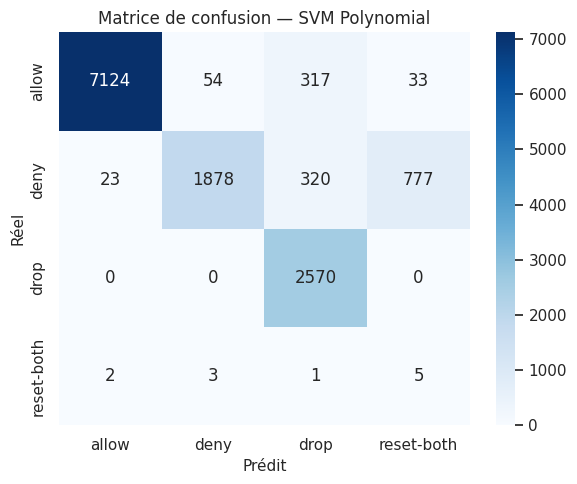

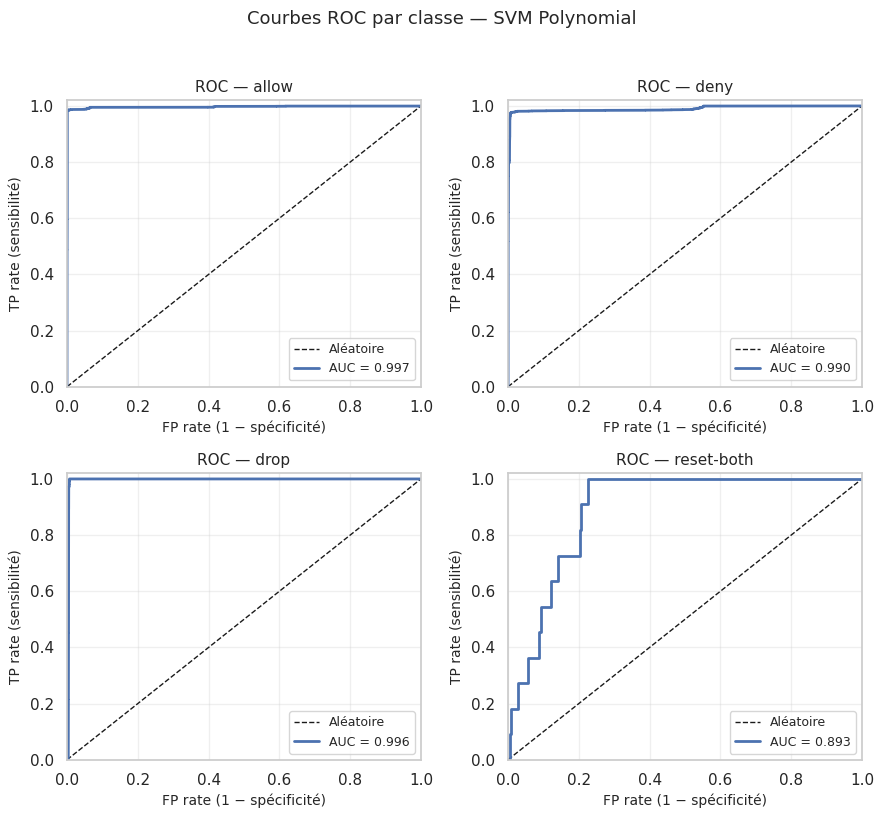


------------------------------------------------------------
  Conseils hyperparamètres — noyau « poly »
------------------------------------------------------------
Référence sklearn.svm.SVC (extraits) :
  C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0,
  class_weight=None, probability=False (nous utilisons probability=True pour les ROC).

Paramètres effectifs du modèle dans cette cellule :
  • C = 1.0
  • kernel = 'poly'
  • degree = 3
  • gamma = 'scale'
  • coef0 = 0.0
  • class_weight = 'balanced'
  • random_state = 69

--- Conseils par noyau ---
• Polynomial : degree (souvent 2–4), C, coef0. Un degré élevé augmente la complexité ; si F1 macro chute, tester degree=2 ou réduire C avant d'augmenter la complexité.

Pour une recherche systématique : utiliser GridSearchCV (fonction `optimize_best_model` dans `firewall_svm.py`) sur le jeu d'entraînement, métrique f1_macro, sans toucher au jeu test jusqu'à l'évaluation finale.


In [6]:
KERNEL = "poly"
pipe, y_pred, metrics = train_eval_kernel(KERNEL, x_train, y_train, x_test, y_test)
RESULTS_STORE[KERNEL] = metrics
PIPE_STORE[KERNEL] = pipe

print_kernel_interpretation(
    KERNEL_DISPLAY_NAMES[KERNEL], y_test, y_pred, CLASS_NAMES, metrics
)
plot_confusion_kernel(
    y_test,
    y_pred,
    CLASS_NAMES,
    "Matrice de confusion — " + KERNEL_DISPLAY_NAMES[KERNEL],
)
y_score = pipe.predict_proba(x_test)
plot_roc_multiclass_single_kernel(
    y_test, y_score, CLASS_NAMES, KERNEL_DISPLAY_NAMES[KERNEL]
)
print_kernel_hyperparam_advice(KERNEL, pipe)


***SVM RBF***



  SVM RBF — scores globaux (moyenne « macro »)
  F1-score (harmonique P/R) : 70.5 %
  Précision                 : 73.2 %
  Rappel (sensibilité)      : 81.6 %
  (L'article Ertam & Kaya rapporte ces trois indicateurs par noyau ; F1 résume le compromis entre précision et rappel.)

--- Interprétation ---
• Le rappel macro domine la précision : le modèle retrouve davantage d'exemples réels par classe, au prix possible de plus de faux positifs.

• Classes peu représentées dans le jeu de test (exemples) : reset-both (n=11). Leur F1 par classe peut peser peu dans la moyenne macro mais être critique pour la sécurité (ex. reset-both).

--- Rapport par classe (support = effectifs test) ---
              precision    recall  f1-score   support

       allow       1.00      0.97      0.98      7528
        deny       0.97      0.75      0.85      2998
        drop       0.95      1.00      0.97      2570
  reset-both       0.01      0.55      0.02        11

    accuracy                           

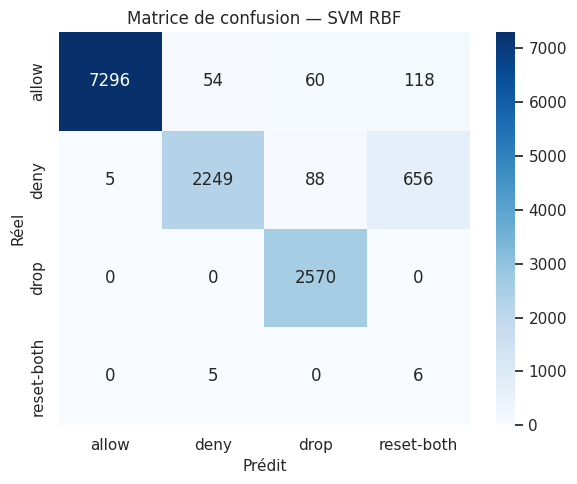

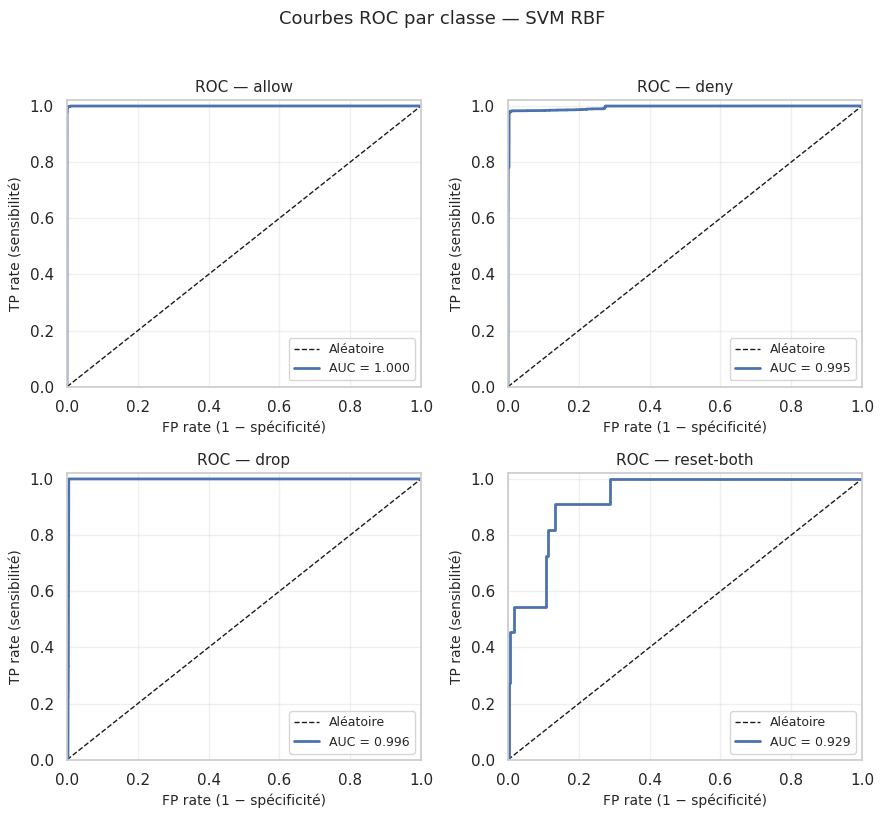


------------------------------------------------------------
  Conseils hyperparamètres — noyau « rbf »
------------------------------------------------------------
Référence sklearn.svm.SVC (extraits) :
  C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0,
  class_weight=None, probability=False (nous utilisons probability=True pour les ROC).

Paramètres effectifs du modèle dans cette cellule :
  • C = 1.0
  • kernel = 'rbf'
  • degree = 3
  • gamma = 'scale'
  • coef0 = 0.0
  • class_weight = 'balanced'
  • random_state = 69

--- Conseils par noyau ---
• RBF : C et gamma dominent. gamma contrôle la portée locale du noyau ; 'scale' ou 'auto' est un bon point de départ. gamma trop grand → frontière très oscillante ; trop petit → presque linéaire.

Pour une recherche systématique : utiliser GridSearchCV (fonction `optimize_best_model` dans `firewall_svm.py`) sur le jeu d'entraînement, métrique f1_macro, sans toucher au jeu test jusqu'à l'évaluation finale.


In [7]:
KERNEL = "rbf"
pipe, y_pred, metrics = train_eval_kernel(KERNEL, x_train, y_train, x_test, y_test)
RESULTS_STORE[KERNEL] = metrics
PIPE_STORE[KERNEL] = pipe

print_kernel_interpretation(
    KERNEL_DISPLAY_NAMES[KERNEL], y_test, y_pred, CLASS_NAMES, metrics
)
plot_confusion_kernel(
    y_test,
    y_pred,
    CLASS_NAMES,
    "Matrice de confusion — " + KERNEL_DISPLAY_NAMES[KERNEL],
)
y_score = pipe.predict_proba(x_test)
plot_roc_multiclass_single_kernel(
    y_test, y_score, CLASS_NAMES, KERNEL_DISPLAY_NAMES[KERNEL]
)
print_kernel_hyperparam_advice(KERNEL, pipe)


***SVM sigmoïde***



  SVM Sigmoid — scores globaux (moyenne « macro »)
  F1-score (harmonique P/R) : 63.0 %
  Précision                 : 68.8 %
  Rappel (sensibilité)      : 66.7 %
  (L'article Ertam & Kaya rapporte ces trois indicateurs par noyau ; F1 résume le compromis entre précision et rappel.)

--- Interprétation ---
• Précision et rappel macro sont proches : compromis relativement équilibré entre faux positifs et faux négatifs au niveau global.

• Classes peu représentées dans le jeu de test (exemples) : reset-both (n=11). Leur F1 par classe peut peser peu dans la moyenne macro mais être critique pour la sécurité (ex. reset-both).

--- Rapport par classe (support = effectifs test) ---
              precision    recall  f1-score   support

       allow       0.99      0.83      0.90      7528
        deny       0.93      0.57      0.71      2998
        drop       0.83      1.00      0.91      2570
  reset-both       0.00      0.27      0.00        11

    accuracy                           0.80  

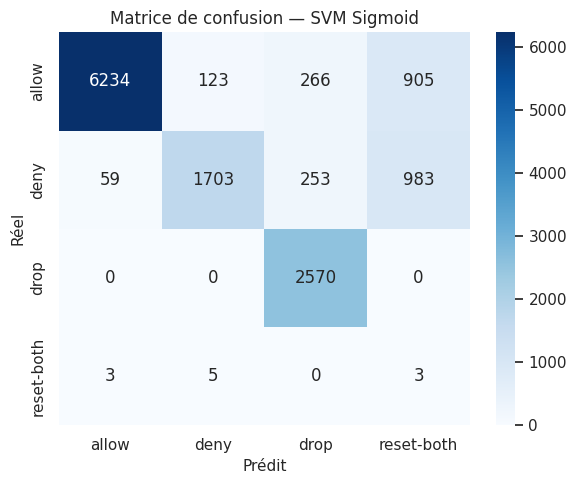

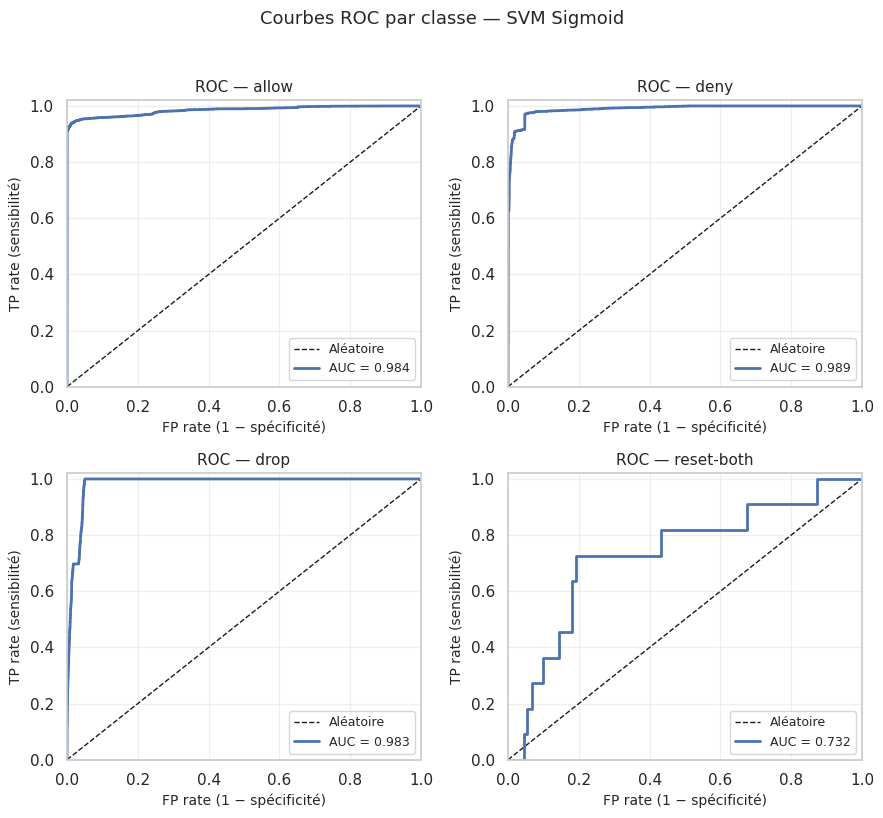


------------------------------------------------------------
  Conseils hyperparamètres — noyau « sigmoid »
------------------------------------------------------------
Référence sklearn.svm.SVC (extraits) :
  C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0,
  class_weight=None, probability=False (nous utilisons probability=True pour les ROC).

Paramètres effectifs du modèle dans cette cellule :
  • C = 1.0
  • kernel = 'sigmoid'
  • degree = 3
  • gamma = 'scale'
  • coef0 = 0.0
  • class_weight = 'balanced'
  • random_state = 69

--- Conseils par noyau ---
• Sigmoid : sensible à gamma et coef0 (similarité avec réseaux). Peut imiter des comportements saturés ; si instable, rapprocher gamma de 'scale' ou ajuster coef0.

Pour une recherche systématique : utiliser GridSearchCV (fonction `optimize_best_model` dans `firewall_svm.py`) sur le jeu d'entraînement, métrique f1_macro, sans toucher au jeu test jusqu'à l'évaluation finale.


In [8]:
KERNEL = "sigmoid"
pipe, y_pred, metrics = train_eval_kernel(KERNEL, x_train, y_train, x_test, y_test)
RESULTS_STORE[KERNEL] = metrics
PIPE_STORE[KERNEL] = pipe

print_kernel_interpretation(
    KERNEL_DISPLAY_NAMES[KERNEL], y_test, y_pred, CLASS_NAMES, metrics
)
plot_confusion_kernel(
    y_test,
    y_pred,
    CLASS_NAMES,
    "Matrice de confusion — " + KERNEL_DISPLAY_NAMES[KERNEL],
)
y_score = pipe.predict_proba(x_test)
plot_roc_multiclass_single_kernel(
    y_test, y_score, CLASS_NAMES, KERNEL_DISPLAY_NAMES[KERNEL]
)
print_kernel_hyperparam_advice(KERNEL, pipe)


***Bilan final — Table III, graphique, et comparaison des runs (classes / reset-both)***



  Référence run CLI (`python firewall_svm.py`) — horodatage
  Filtre source : 'log2.csv'
  Dossier      : run-20260413T034330Z/
  Début (UTC)  : 2026-04-13T03:43:30.715645Z
  Fin (UTC)    : 2026-04-13T03:55:32.387813Z
  Source données: 'log2.csv'
  Meilleur noyau (F1 macro) : SVM RBF
  F1 classe « reset-both » (meilleur noyau, avant grille) : 1.52 %
  Seuil reset-both retenu (après calibration) : 0.0076
  F1 classe « reset-both » (après calibration seuil) : 3.81 %
  Fichier trace : /workspace/run-20260413T034330Z/resultats.txt
  Manifest JSON : /workspace/run-20260413T034330Z/run_manifest.json

Tableau récapitulatif (nos expériences) — mêmes colonnes que Ertam & Kaya, Table III :
                F1 Score  Precision  Recall
Méthode                                    
SVM Linear          68.7       74.3    83.1
SVM Polynomial      65.8       69.4    75.7
SVM RBF             70.5       73.2    81.6
SVM Sigmoid         63.0       68.8    66.7

  Bilan harmonisé — métriques macro (%) vs Er

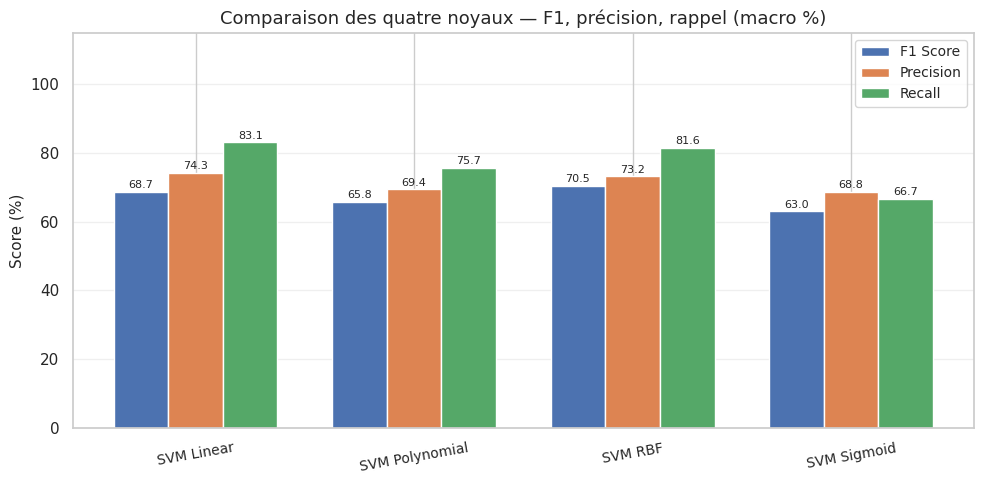


  Calibration du seuil reset-both — bilan
  Cible de sélection          : 'reset-both_f1'
  Seuil retenu                : 0.0076

  Métrique                   Défaut(0.50)  Seuil sélectionné          Δ
  --------------------------------------------------------------------
  Macro F1                          70.72              73.94       3.22
  Macro Recall                      83.64              85.70       2.06
  Macro Precision                   74.16              74.54       0.38
  reset-both F1                      1.71               3.81       2.10
  reset-both Recall                 63.64              54.55      -9.09
  reset-both Precision               0.86               1.97       1.11

  Bilan multi-runs — déséquilibre des classes et sort « reset-both »

• Déséquilibre typique (jeu de test) : la classe « reset-both » a un support très faible par rapport à « allow » ; le ratio max/min sur le test est indiqué dans chaque manifest (`test_support_ratio`).

--- Run le moins favo

In [9]:
from pathlib import Path

ROOT = Path.cwd()
SRC_FILTER = DATA_SOURCE if DATA_SOURCE else None
print_latest_run_legend(ROOT, SRC_FILTER)

results_df = build_results_dataframe(RESULTS_STORE, KERNEL_DISPLAY_NAMES, KERNEL_KEYS)
print("\nTableau récapitulatif (nos expériences) — mêmes colonnes que Ertam & Kaya, Table III :")
print(results_df.to_string())
print_article_vs_experiment(results_df, ARTICLE_TABLE_III)
plot_comparison_bar(
    results_df,
    title="Comparaison des quatre noyaux — F1, précision, rappel (macro %)",
)

latest_path, latest_manifest = latest_finished_manifest(ROOT, SRC_FILTER)
if latest_manifest is not None and latest_manifest.get("threshold_tuning"):
    print_threshold_tuning_bilan(latest_manifest)
else:
    print("\n[threshold] Aucun run complet avec calibration de seuil trouvé pour cette source.")
    print("[threshold] Démonstration rapide sur un sous-échantillon stratifié...")

    # Démonstration légère pour visualiser le comportement des seuils sans relancer le pipeline complet.
    small_df_parts = []
    for cls in CLASS_NAMES:
        cls_df = df[df["Action"] == cls]
        take_n = min(len(cls_df), 1200 if cls != "reset-both" else len(cls_df))
        small_df_parts.append(cls_df.sample(n=take_n, random_state=RANDOM_STATE))
    small_df = pd.concat(small_df_parts, axis=0).sample(frac=1.0, random_state=RANDOM_STATE)

    x_small, y_small = select_features(None, small_df)
    x_train_s, x_test_s, y_train_s, y_test_s = prepare_data(None, x_small, y_small)

    # Le meilleur noyau de la section précédente sert d'entrée à optimize_best_model.
    best_kernel_display = results_df["F1 Score"].idxmax()
    payload = optimize_best_model(None, best_kernel_display, x_train_s, y_train_s, x_test_s, y_test_s)
    demo_manifest = {
        "threshold_tuning": {
            "selection_target": payload["threshold_selection_target"],
            "selected_reset_both_threshold": payload["selected_reset_both_threshold"],
            "test_threshold_results": payload["test_threshold_results"],
        }
    }
    print_threshold_tuning_bilan(demo_manifest)

print_crossrun_class_imbalance_bilan(ROOT, SRC_FILTER)
